[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bniko05/sentiment-and-image-classification/blob/main/notebooks/02_imdb_bilstm_attention.ipynb)

# IMDB Sentiment Analysis: Stacked BiLSTM with Attention (PyTorch)

A 3-layer bidirectional LSTM over pre-trained **GloVe** embeddings, with a self-attention layer that weights the most informative words.

> ⚡ In Colab, select **Runtime → Change runtime type → T4 GPU** before running. The notebook downloads GloVe (~800 MB).

In [1]:
#εγκατάσταση του pytorch

!pip install torch torchtext nltk matplotlib scikit-learn
!python -m nltk.downloader stopwords

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.7 MB/s eta 0:00:00
<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
#Imports των απαραίτητων βιβλιοθηκών

import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.model_selection import train_test_split
from collections import Counter
import nltk
from nltk.corpus import stopwords
import re

In [3]:
#Φόρτωση των κριτικών των ταινιών

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words = 15000, skip_top = 50, seed = 42)

word_index = tf.keras.datasets.imdb.get_word_index()

x_train, x_temp, y_train, y_temp = train_test_split(x_train, y_train, test_size = 0.2, random_state = 42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size = 0.5, random_state = 42)

max_voc_size = 15000

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
word_index = {word:(index + 2) for word,index in word_index.items()}
word_index['PAD'] = 0
word_index['START'] = 1
word_index['UNK'] = 2

index_to_word = {index:word for word,index in word_index.items()}

max_voc_size += 3
voc_size = max_voc_size

In [5]:
#Κατέβασμα των word_embeddings

!wget https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-01-16 18:28:07--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  5.09MB/s    in 2m 39s  

2026-01-16 18:30:46 (5.18 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]



In [6]:
#Φόρτωση των word_embeddings και δημιουργία του πίνακα με αυτά

glove_embeddings = {}
with open('glove.6B.200d.txt', encoding='utf-8') as embs:
    for line in embs:
        word_values = line.split()
        word = word_values[0]
        values = np.asarray(word_values[1:], dtype='float32')
        glove_embeddings[word] = values

embedding_dim = 200
embedding_matrix = np.zeros((voc_size, embedding_dim))

for i in range(voc_size):
    word = index_to_word.get(i, 'UNK')
    if word in glove_embeddings:
        embedding_matrix[i] = glove_embeddings[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))

In [7]:
#Δημιουργία Dataset και αρχικοποίηση

class IMDBDataset(Dataset):
    def __init__(self, reviews, labels, max_length):
        self.reviews = reviews
        self.labels = labels
        self.max_length = max_length

    def padding(self, word):
        if(len(word) < self.max_length):
            return word + [0] * (self.max_length - len(word)) #βαζουμε το 0 γιατί αυτό αντιστοιχεί στο padding 'PAD'
        else:
            return word[:self.max_length]

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, idx):
        review = self.padding(self.reviews[idx])
        label = self.labels[idx]
        return torch.tensor(review, dtype = torch.long), torch.tensor(label, dtype = torch.float)


train_dataset = IMDBDataset(x_train, y_train, max_length = 400)
val_dataset = IMDBDataset(x_val, y_val, max_length = 400)
test_dataset = IMDBDataset(x_test, y_test, max_length = 400)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 64)
test_loader = DataLoader(test_dataset, batch_size = 64)

In [8]:
from tensorflow.python.eager import context
#Ορισμός του μοντέλου(RNN με LSTM)

class StackedBiRNNLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers = 3, dropout = 0.5, use_attention = False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = 0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.requires_grad = True

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers = num_layers, bidirectional = True, batch_first= True, dropout = dropout if num_layers > 1 else 0)

        self.use_attention = use_attention

        if(use_attention):
            self.attention = nn.Sequential(nn.Linear(hidden_dim * 2, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 1))
        else:
            self.attention = None

        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))

        lstm_out, _ = self.lstm(embedded)

        if(self.use_attention):
          attention_weights = self.attention(lstm_out)
          attention_weights = torch.softmax(attention_weights, dim=1)

          context = torch.sum(attention_weights * lstm_out, dim=1)
        else:
          context, _ = torch.max(lstm_out, dim = 1)

        fc_out = self.fc(self.dropout(context))

        return torch.sigmoid(fc_out.squeeze())


In [9]:
#Αρχικοποιήση Μοντέλου και βελτιστοποιήση του

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = StackedBiRNNLSTM(vocab_size = voc_size, embedding_dim = embedding_dim, hidden_dim = 192, output_dim = 1, num_layers = 3, dropout = 0.5, use_attention = True)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr = 0.0005)
criterion = nn.BCELoss()

In [10]:
#Συνάρτηση Εκπαίδευσης

def train_in_epoch(model, train_loader, optimizer, criterion):
    model.train()
    epoch_loss = 0

    for batch_index, (text, labels) in enumerate(train_loader):
        text = text.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(text).squeeze()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(train_loader)

In [11]:
#Συνάρτηση Αξιολόγησης

def evaluate(model, test_loader, criterion):
    model.eval()
    epoch_loss = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for texts, labels in test_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts).squeeze()
            preds = (outputs > 0.5).cpu().numpy()
            loss = criterion(outputs, labels)

            epoch_loss += loss.item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds)

    accuracy = accuracy_score(y_true, y_pred)

    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

    micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='micro', zero_division=0)

    metrics_per_class = {}
    metrics_per_class['positive'] = [precision_per_class[1], recall_per_class[1], f1_per_class[1]]
    metrics_per_class['negative'] = [precision_per_class[0], recall_per_class[0], f1_per_class[0]]

    average_metrics = {
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'micro_precision': micro_precision,
        'micro_recall': micro_recall,
        'micro_f1': micro_f1
    }

    return epoch_loss / len(test_loader), accuracy, average_metrics, metrics_per_class

In [12]:
#Εκπαίδευση μοντέλου

epochs = 15
patience = 2
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss = train_in_epoch(model, train_loader, optimizer, criterion)
    train_losses.append(train_loss)

    val_loss, _, _, _ = evaluate(model, val_loader, criterion)
    val_losses.append(val_loss)

    print("Epoch: " + str(epoch + 1) + " out of " + str(epochs))
    print("Training Loss: " + str(round(train_loss, 4)))
    print("Validation Loss: " + str(round(val_loss, 4)))

    if(val_loss < best_val_loss):
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if(patience_counter >= patience):
            print("Πρόωρο σταμάτημα")
            break



Epoch: 1 out of 15
Training Loss: 0.6524
Validation Loss: 0.4497
Epoch: 2 out of 15
Training Loss: 0.3922
Validation Loss: 0.3009
Epoch: 3 out of 15
Training Loss: 0.2992
Validation Loss: 0.2738
Epoch: 4 out of 15
Training Loss: 0.253
Validation Loss: 0.2663
Epoch: 5 out of 15
Training Loss: 0.2177
Validation Loss: 0.2876
Epoch: 6 out of 15
Training Loss: 0.1811
Validation Loss: 0.2705
Πρόωρο σταμάτημα


In [13]:
#Αξιολόγηγη του μοντέλου
model.load_state_dict(torch.load('best_model.pth'))
test_loss, test_acc, average_metrics, metrics_per_class = evaluate(model, test_loader, criterion)

print("\n" + "="*60)
print("Αποτελέσματα")
print("="*60)
print("-"*60)
print("Loss: " + str(round(test_loss,4)))
print("Accuracy: " + str(round(test_acc,4)))
print("-"*60)


print("\n" + "="*60)
print("Αποτελέσματα Για Κάθε Κλάση")
print("="*60)
print(f"{'Κλάση':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*60)

for class_name in ['positive', 'negative']:
    print(f"{class_name:<15} {metrics_per_class[class_name][0]:<12.4f} {metrics_per_class[class_name][1]:<12.4f}{metrics_per_class[class_name][2]:<12.4f}")

print("-"*60)

print("\n" + "="*60)
print("Κύριες Μετρικές")
print("="*60)
print(f"{'Μέτρηση':<20} {'Τιμή':<12}")
print("-"*60)
print(f"{'Macro Precision':<20} {average_metrics['macro_precision']:<12.4f}")
print(f"{'Macro Recall':<20} {average_metrics['macro_recall']:<12.4f}")
print(f"{'Macro F1':<20} {average_metrics['macro_f1']:<12.4f}")
print(f"{'Micro Precision':<20} {average_metrics['micro_precision']:<12.4f}")
print(f"{'Micro Recall':<20} {average_metrics['micro_recall']:<12.4f}")
print(f"{'Micro F1':<20} {average_metrics['micro_f1']:<12.4f}")
print("-"*60)


Αποτελέσματα
------------------------------------------------------------
Loss: 0.2534
Accuracy: 0.8924
------------------------------------------------------------

Αποτελέσματα Για Κάθε Κλάση
Κλάση           Precision    Recall       F1-Score    
------------------------------------------------------------
positive        0.8813       0.9111      0.8959      
negative        0.9047       0.8731      0.8886      
------------------------------------------------------------

Κύριες Μετρικές
Μέτρηση              Τιμή        
------------------------------------------------------------
Macro Precision      0.8930      
Macro Recall         0.8921      
Macro F1             0.8923      
Micro Precision      0.8924      
Micro Recall         0.8924      
Micro F1             0.8924      
------------------------------------------------------------


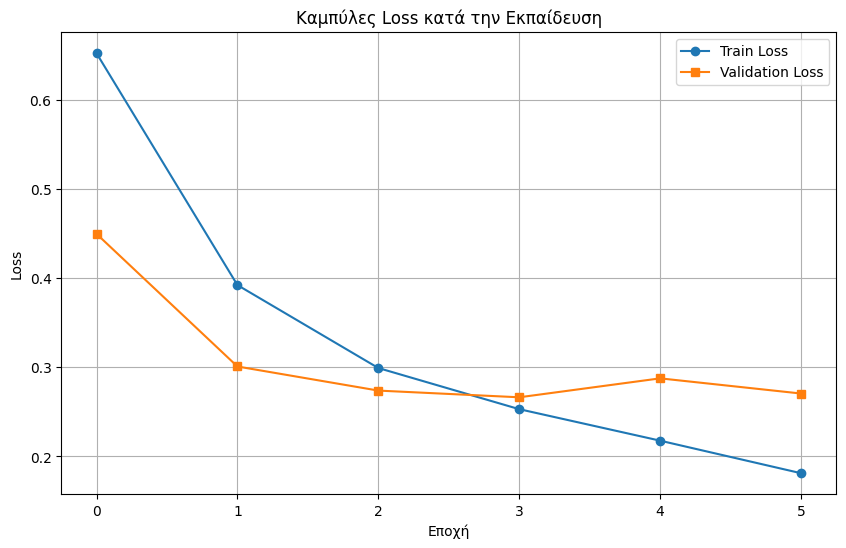

In [14]:
#Καμπύλες Loss

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Εποχή')
plt.ylabel('Loss')
plt.title('Καμπύλες Loss κατά την Εκπαίδευση')
plt.legend()
plt.grid(True)
plt.show()